In [10]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import scanpy as sc
import matplotlib.pyplot as plt

In [11]:
import logging
import json
import os
import re
from collections import Counter
from pathlib import Path

import anndata
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import torch
import torchvision.transforms.functional as TF
import tifffile


In [3]:
def listfiles(folder, regex=None):
    """Return all files with the given regex in the given folder structure"""
    for root, folders, files in os.walk(folder):
        for filename in folders + files:
            if regex is None:
                yield os.path.join(root, filename)
            elif re.findall(regex, os.path.join(root, filename)):
                yield os.path.join(root, filename)

In [4]:
def display_fovs(cosmx_dir, flatfiles_dir=None):
    dirpath = cosmx_dir if flatfiles_dir is None else flatfiles_dir
    dirpath = Path(dirpath)
    assert dirpath.is_dir(), f'{dirpath} is not a directory'

    fov_metadata_fp = list(listfiles(dirpath, regex=r'\/[^\.][^\/]*fov_positions_file.csv.gz$'))[0]
    print(fov_metadata_fp)
    fov_metadata = pd.read_csv(fov_metadata_fp)
    
    x_col, y_col = 'x_global_mm', 'y_global_mm'
    if 'X_mm' in fov_metadata.columns:
        x_col, y_col = 'X_mm', 'Y_mm'
    
    
    sns.scatterplot(data=fov_metadata, x=x_col, y=y_col)
    plt.gca().invert_yaxis()
    plt.axis('equal')

In [5]:
def adjust_metadata_col_names(cols):
    """
    Adjusts column names because they change in 6k vs 1k
    """
    cols = [x.replace('_global', '') for x in cols]
    cols = [x[0].upper() + x[1:] for x in cols]
    return cols


def adata_from_cosmx(filepath, img_channel='DNA', scaler=.1, normalize=False, sample_to_bbox=None, base=10, flatfiles_dir=None, morphology_dir=None, version='v1'):
    if filepath.split('.')[-1] == 'h5ad':
        # sample_to_adata = {'sample': sc.read_h5ad(filepath)}
        return sc.read_h5ad(filepath)
    else:
        if sample_to_bbox is None:
            sample_to_bbox['sample'] = (0, 1000, 0, 1000) # just make arbitrarily large
        
        dirpath = flatfiles_dir if flatfiles_dir is not None else filepath
        dirpath = Path(dirpath)
        assert dirpath.is_dir(), f'flatfiles directory does not exist in {filepath}'
        
        metadata_fp = list(listfiles(dirpath, regex=r'\/[^\.][^\/]*metadata_file.csv.gz$'))[0]
        exp_fp = list(listfiles(dirpath, regex=r'\/[^\.][^\/]*exprMat_file.csv.gz$'))[0]
        fov_metadata_fp = list(listfiles(dirpath, regex=r'\/[^\.][^\/]*fov_positions_file.csv.gz$'))[0]
        transcripts_fp = list(listfiles(dirpath, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]
        assert os.path.exists(transcripts_fp), f'transcripts filepath does not exist {transcripts_fp}'

        morphology_dir = filepath if morphology_dir is None else morphology_dir
        morphology_dir = Path(morphology_dir)
        assert morphology_dir.is_dir(), f'morphology directory does not exist in {morphology_dir}'
        
        fov_fps = sorted(listfiles(morphology_dir, regex=r'Morphology2D.*TIF$'))
        fov_to_fp = {int(re.sub(r'^.*F0*([1-9]+[0-9]*).TIF$', r'\1', fp)):fp for fp in fov_fps}

        metadata = pd.read_csv(metadata_fp, index_col='cell')
        fov_metadata = pd.read_csv(fov_metadata_fp)
        fov_metadata.columns = adjust_metadata_col_names(fov_metadata.columns)

        exp_df = pd.read_csv(exp_fp, index_col='cell_ID')
        to_remove = ['fov', 'Negative', 'SystemControl']
        exp_df = exp_df[[c for c in exp_df.columns
                    if not len([x for x in to_remove if x in c])]]
        exp_df = exp_df[[c for c in exp_df.columns if c != 'cell']]

        transcripts_df = pd.read_csv(transcripts_fp, sep=',')

        tf = tifffile.TiffFile(fov_fps[0])
        img_metadata = json.loads(next(iter(tf.pages)).description)

        img_ppm = 1 / img_metadata['PixelSize_um'] # is pixels per micron, we want microns per pixel
        channel_ids = img_metadata['ChannelOrder']
        channel_id_to_name = {d['Fluorophore']['ChannelId']:d['BiologicalTarget']
                            for d in img_metadata['MorphologyKit']['MorphologyReagents']}
        channels = [channel_id_to_name[cid] for cid in channel_ids]
        channel_idx = channels.index(img_channel)


        tile_size = (len(channel_ids), img_metadata['ImRows'], img_metadata['ImCols'])
        
        sample_to_adata, sample_to_stitched, sample_to_transcripts = {}, {}, {}
        for sample, (r1, r2, c1, c2) in sample_to_bbox.items():
            logging.info(f'extracting {sample}, bbox is {(r1, r2, c1, c2)}')
            fov_mask = (
                (fov_metadata['X_mm'] >= c1) &
                (fov_metadata['X_mm'] <= c2) &
                (fov_metadata['Y_mm'] >= r1) &
                (fov_metadata['Y_mm'] <= r2)
            )
            fov_meta = fov_metadata[fov_mask]
            x_vals, y_vals = sorted(set(fov_meta['X_mm'].to_list())), sorted(set(fov_meta['Y_mm'].to_list()))
            fov_to_pos = {i:(y_vals.index(y), x_vals.index(x)) for i, y, x in zip(fov_meta['FOV'], fov_meta['Y_mm'], fov_meta['X_mm'])} 

            cell_mask = [True if fov in fov_to_pos else False for fov in metadata['fov'].to_list()]
            cell_meta = metadata[cell_mask]
            cell_exp = exp_df[cell_mask]

            stitched = np.zeros((tile_size[0], tile_size[1] * len(y_vals), tile_size[2] * len(x_vals)), dtype=np.uint8)
            cell_to_xy = {}
            new_transcripts = None
            for fov, (y, x) in fov_to_pos.items():
                print(f'reading fov {fov}')
                logging.info(f'reading fov {fov}')
                f = metadata[metadata['fov']==fov]
                transcripts_f = transcripts_df[transcripts_df['fov'] == fov]

#                 tile = tifffile.imread(fov_to_fp[fov])

#                 if version == 'v1':
#                     tile = np.flip(tile, axis=-2)
#                 elif version == 'v2':
#                     tile = np.flip(tile, axis=-1)


#                 r1, r2 = y * tile.shape[-2], (y + 1) * tile.shape[-2]
#                 c1, c2 = x * tile.shape[-1], (x + 1) * tile.shape[-1]

#                 tile = tile.astype(np.float32)
#                 tile /= 65535.
#                 tile *= 255.
#                 tile = tile.astype(np.uint8)

#                 stitched[:, r1:r2, c1:c2] = tile

                transcripts_f['x_local_px'] = transcripts_f['x_local_px'] + c1
                transcripts_f['y_local_px'] = np.abs(transcripts_f['y_local_px'] - tile_size[-2]) + r1

                ys = np.abs(f['CenterY_local_px'] - tile_size[-2])
                for cell_id, x, y in zip(f.index.to_list(), f['CenterX_local_px'], ys):
                    if version == 'v1':
                        cell_to_xy[cell_id] = (x + c1, y + r1)
                    elif version == 'v2':
                        cell_to_xy[cell_id] = (x - c1, y - r1)
                    else:
                        raise RuntimeError('version does not exist')
                
                if new_transcripts is None:
                    new_transcripts = transcripts_f
                else:
                    new_transcripts = pd.concat((new_transcripts, transcripts_f))

#             resized = TF.resize(
#                 torch.tensor(stitched),
#                 (int(stitched.shape[-2] * scaler), int(stitched.shape[-1] * scaler)),
#                 antialias=True
#             ).numpy()

#             if version == 'v2':
#                 resized = np.flip(resized, (-1, -2))

#             img_dict = {'hires': resized[channel_idx]}
#             img_dict.update({f'hires_{k}':v for k, v in zip(channels, resized)})

            adata = anndata.AnnData(X=cell_exp.values, obs=cell_meta)
            adata.var.index = cell_exp.columns
            adata.var.index.name = 'gene'

            adata.obsm['spatial'] = np.stack((
                np.asarray([cell_to_xy[cid][0] for cid in adata.obs.index.to_list()]),
                np.asarray([cell_to_xy[cid][1] for cid in adata.obs.index.to_list()]),
            )).swapaxes(1, 0)
            
            if version == 'v2':
                offset = np.asarray([stitched.shape[-1] - tile_size[-1], stitched.shape[-2] - tile_size[-2]])
                adata.obsm['spatial'] += offset
                new_transcripts['x_local_px'] += offset[0]
                new_transcripts['y_local_px'] += offset[1]

#             sfs = {'spot_diameter_fullres': 10.}
#             sfs.update({f'tissue_{k}_scalef':scaler for k in img_dict})

#             adata.uns['spatial'] = {
#                 sample: {
#                     'images': img_dict,
#                     'scalefactors': sfs
#                 }
#             }

            adata.uns['ppm'] = img_ppm
        
            sample_to_adata[sample] = adata
#             sample_to_stitched[sample] = stitched
            sample_to_transcripts[sample] = new_transcripts

    
    for sid, adata in sample_to_adata.items():
        # if sparse, then convert
        if 'sparse' in str(type(adata.X)).lower():
            adata.X = adata.X.toarray()

        if normalize:
            sc.pp.log1p(adata, base=base)

        sample_to_adata[sid] = adata
    
    # if len(sample_to_adata) <= 1:
    #     return next(iter(sample_to_adata.values()))
    return sample_to_adata, channels, sample_to_transcripts

## define inputs

In [12]:
output_dir = Path('../data/spatial/inputs/cosmx')

In [13]:

mapping = {
    'HT891Z1-S2H3FP1U57': (0, 7, 0, 10),
    'HT891Z1-S2H3FP1U60': (7, 15, 0, 10),
}

cosmx_dir = '../../cosmx/20241112_118452_HT891Z1-S2H3FP1Us1__HT891Z1-S2H3FP1Us2'
flatfiles_dir = '../../cosmx/20241112_118452_HT891Z1-S2H3FP1Us1__HT891Z1-S2H3FP1Us2/flatfiles/transfer_v1.3'
morphology_dir = '../../cosmx/20241112_118452_HT891Z1-S2H3FP1Us1__HT891Z1-S2H3FP1Us2/HE8_HT891Z1S2H3Fp1_serialsec1_serialsec2/20241113_022628_S1/CellStatsDir/Morphology2D'
transcripts_fp = list(listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:
#check
mapping = {
    'HT913Z1-S1H1Fp1': (0, 1, 0, 1),
    'HT891Z1-S2H1Fp1': (0, 7, 0, 10),
    'HT891Z1-S2H4Fp1': (7, 15, 0, 10),
}

cosmx_dir = '../../cosmx/20240827_118454_HT913Z1-S1H1Fp1_HT891Z1-S2H1Fp1_HT891Z1-S2H4Fp1'
flatfiles_dir = '../../cosmx/20240827_118454_HT913Z1-S1H1Fp1_HT891Z1-S2H1Fp1_HT891Z1-S2H4Fp1/flatfiles/transfer_v1.3'
morphology_dir = '../../cosmx/20240827_118454_HT913Z1-S1H1Fp1_HT891Z1-S2H1Fp1_HT891Z1-S2H4Fp1/HT891Z1S2H4FP1_LEFTTOP_HT891Z1S2H1FP1_RIGHTTOP_HT913Z1S1H1FP1_BOTTOMCENTER/20240821_013854_S2/CellStatsDir/Morphology2D'
transcripts_fp = list(listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:

mapping = {
    'HT704B1-S1H3Fp1_U14': (0, 5, 0, 10),
    'HT704B1-S1H3Fp1_U22': (6, 14, 0, 10),
}

cosmx_dir = '../../cosmx/HT704B1-S1H3Fp1U14___HT704B1-S1H3Fp1U22'
flatfiles_dir = '../../cosmx/HT704B1-S1H3Fp1U14___HT704B1-S1H3Fp1U22/flatfiles/transfer_v1.3'
morphology_dir = '../../cosmx/HT704B1-S1H3Fp1U14___HT704B1-S1H3Fp1U22/HT704B1_S1H3Fp1slide8/20240620_214004_S1/CellStatsDir/Morphology2D'
transcripts_fp = list(utils.listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:

mapping = {
    'HT704B1-S1H3Fp1_U47': (0, 5, 0, 10),
    'HT704B1-S1H3Fp1_U56': (6, 14, 0, 10),
}

cosmx_dir = './../cosmx/HT704B1-S1H3Fp1U56___HT704B1-S1H3Fp1U47'
flatfiles_dir = './../cosmx/HT704B1-S1H3Fp1U56___HT704B1-S1H3Fp1U47/flatfiles/transfer_v1.3'
morphology_dir = './../cosmx/HT704B1-S1H3Fp1U56___HT704B1-S1H3Fp1U47/HT704B1_S1H3Fp1slide19/20240620_214004_S2/CellStatsDir/Morphology2D'
transcripts_fp = list(utils.listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:

mapping = {
    'HT206B1-H2L1U23_1': (0, 6, 0, 6),
}

cosmx_dir = './../cosmx/HT206B1-H2L1U15_1___HT206B1-H2L1U23_1'
flatfiles_dir = './../cosmx/HT206B1-H2L1U15_1___HT206B1-H2L1U23_1/flatfiles'
morphology_dir = './../cosmx/HT206B1-H2L1U15_1___HT206B1-H2L1U23_1/7206B1H2L1/20240112_213110_S4/CellStatsDir/Morphology2D'
transcripts_fp = list(utils.listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:
## check
mapping = { 
    'SP012Z1-Fp1A2-Ux': (0, 15, 0, 15),
}

cosmx_dir = '../../cosmx/S21-11816A2_S21-44455'
flatfiles_dir = '../../cosmx/S21-11816A2_S21-44455/flatfiles'
morphology_dir = '../../cosmx/S21-11816A2_S21-44455/S2111816A2_S2144455/20231109_220050_S2/CellStatsDir/Morphology2D'
transcripts_fp = list(listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:
## check
mapping = { 
    'SP005Z1-Fp1A25-Ux': (0, 15, 0, 15),
    'SP012Z1-Fp1A15-Ux': (0, 15, 0, 15),
}

cosmx_dir = '../../cosmx/Prostate_S18-11798A15_S18-18215A25_run_2023-12-02'
flatfiles_dir = '../../cosmx/Prostate_S18-11798A15_S18-18215A25_run_2023-12-02/flatfiles/'
morphology_dir = '../../cosmx/Prostate_S18-11798A15_S18-18215A25_run_2023-12-02/Prostate_S1811798A15_S1818215A25/20231128_231410_S3/CellStatsDir/Morphology2D'
transcripts_fp = list(listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

In [ ]:
## check
mapping = { 
    'HT938Z1-S1H1FP1U1': (0, 15, 0, 15),
    'HT997Z1-S1H1FP1U1': (0, 15, 0, 15),
    'HT935Z1-S1H1FP1U2': (0, 15, 0, 15),
}

cosmx_dir = '../../cosmx/20241205_116645_HT938Z1-S1H1FP1U1__HT997Z1-S1H1FP1U1__HT935Z1-S1H1FP1U2'
flatfiles_dir = '../../cosmx/20241205_116645_HT938Z1-S1H1FP1U1__HT997Z1-S1H1FP1U1__HT935Z1-S1H1FP1U2/flatfiles/transfer_v1.3/'
morphology_dir = '../../cosmx/20241205_116645_HT938Z1-S1H1FP1U1__HT997Z1-S1H1FP1U1__HT935Z1-S1H1FP1U2/HT938Z1_S1H1FP1U1_TOP_HT997Z1_S1H1FP1U1_LEFTBOTTOM_HT935Z1S1H1FP1U1_RIGHTBOTTOM/20241204_225613_S1/CellStatsDir/Morphology2D'
transcripts_fp = list(listfiles(flatfiles_dir, regex=r'\/[^\.][^\/]*tx_file.csv.gz$'))[0]

assert os.path.exists(transcripts_fp)

## process

../../cosmx/20241112_118452_HT891Z1-S2H3FP1Us1__HT891Z1-S2H3FP1Us2/flatfiles/transfer_v1.3/HE8_HT891Z1S2H3Fp1_serialsec1_serialsec2_fov_positions_file.csv.gz


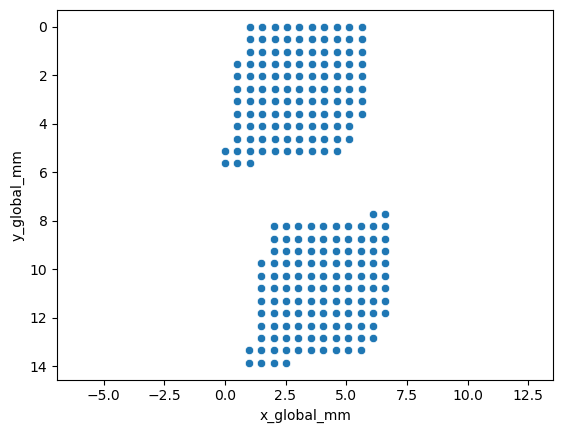

In [14]:
display_fovs(cosmx_dir, flatfiles_dir=flatfiles_dir, )

In [ ]:
sample_to_adata, channels, sample_to_transcripts = adata_from_cosmx(
    cosmx_dir, flatfiles_dir=flatfiles_dir, morphology_dir=morphology_dir,
    sample_to_bbox=mapping, scaler=.1)
sample_to_adata.keys()

In [ ]:
for sample, adata in sample_to_adata.items():
    print(sample)
    adata = sample_to_adata[sample]
    data = sample_to_stitched[sample]
    transcripts = sample_to_transcripts[sample]

    output_filepath = output_dir / f'{sample}_initial.h5ad'
    adata.write_h5ad(output_filepath)
    
    output_filepath = output_dir / f'{sample}_transcripts.parquet'
    transcripts.to_parquet(output_filepath)
    
    
    

